# Statewide races

Note: 'current' results are currently pointing to 2022 results, so as to be able to verify the model is working.

In [19]:
import pandas as pd

regions_nonmetro = pd.read_csv('./regions/regions_nonmetro.csv', index_col='County')
regions_nonmetro

,Region,Subregion
County,,
Banks,East,Outer East Georgia
Barrow,East,Metro Athens
Clarke,East,Metro Athens
Elbert,East,Outer East Georgia
Franklin,East,Outer East Georgia
...,...,...
Heard,West,Newnan-LaGrange
Meriwether,West,Newnan-LaGrange
Paulding,West,Carrollton-Paulding


Text(0.5, 1.0, 'Non-Metro Regions')

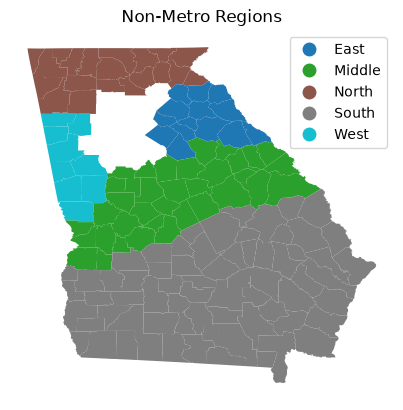

In [3]:
import utils

counties = utils.import_county_map()
counties['Region'] = regions_nonmetro['Region']
regions = counties['Region'].unique()
ax = counties.plot(column='Region', legend=True)
ax.set_axis_off()
ax.set_title('Non-Metro Regions')

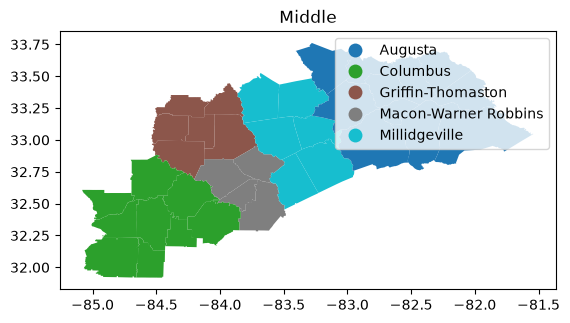

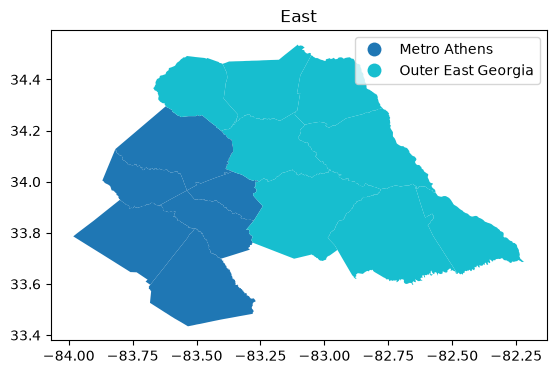

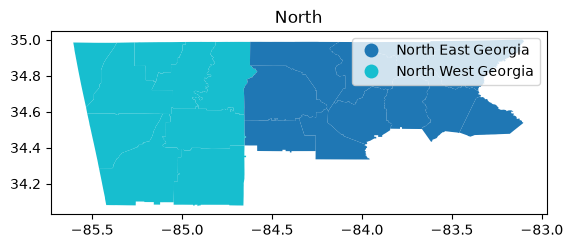

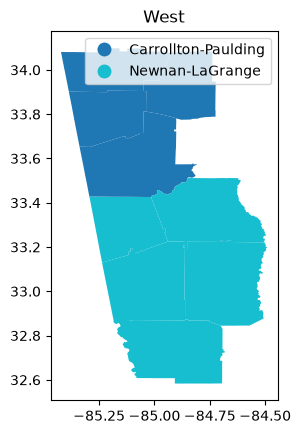

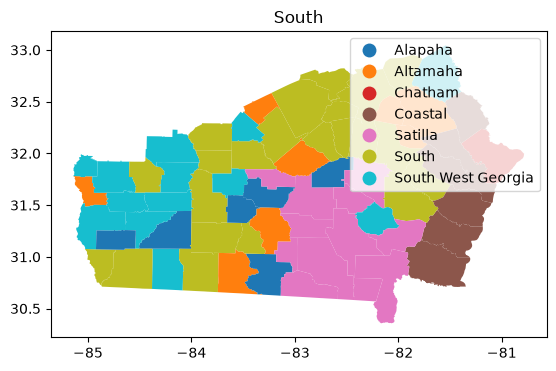

In [4]:
counties['Subregion'] = regions_nonmetro['Subregion']

for region in regions:
    if str(region) == 'nan':
        continue
    counties_f = counties[counties['Region'] == region]
    ax = counties_f.plot(column='Subregion', legend=True)
    ax.set_title(region)


In [24]:
import geopandas

regions_metro = geopandas.read_file('./regions/regions_metro.json')
regions_metro.set_index('index')

,County,Reporting Group,Subregion,Election,Region,geometry
index,,,,,,
AIR ACRES,Cherokee,AIR ACRES,Holly Springs,*,North Metro Atlanta,"POLYGON ((-84.4856 34.11594, -84.48539 34.1161..."
ARNOLD MILL,Cherokee,ARNOLD MILL,Holly Springs,*,North Metro Atlanta,"POLYGON ((-84.43107 34.10415, -84.43122 34.104..."
AVERY,Cherokee,AVERY,Canton-Waleska-Ball Ground,*,North Metro Atlanta,"POLYGON ((-84.36133 34.13702, -84.36177 34.137..."
BALL GROUND,Cherokee,BALL GROUND,Canton-Waleska-Ball Ground,*,North Metro Atlanta,"POLYGON ((-84.39359 34.30172, -84.39349 34.301..."
BASCOMB,Cherokee,BASCOMB,Woodstock,*,North Metro Atlanta,"POLYGON ((-84.57311 34.15381, -84.57358 34.152..."
...,...,...,...,...,...,...
HI,Rockdale,HI-MI Precinct Reporting Group 0,Rockdale,2022,South Metro Atlanta,"POLYGON ((-83.96181 33.68735, -83.96187 33.687..."
LO,Rockdale,LO,Rockdale,2022,South Metro Atlanta,"POLYGON ((-84.18414 33.64616, -84.17018 33.645..."
BA,Rockdale,BA,Rockdale,2022,South Metro Atlanta,"POLYGON ((-84.08058 33.55454, -84.08083 33.554..."


In [5]:
def import_historical(year, office):
    return pd.read_csv(f'./data/{year}_{office}.csv', index_col=['County', 'Vote Method'])

In [6]:
def display_single_results(df):
    res = df.sum()
    res = pd.DataFrame(res, columns=['Votes'])
    res = res.sort_values(by='Votes', ascending=False)
    res['Share'] = (res['Votes'] / res['Votes'].sum() * 100)
    return res

# Import Results

In [7]:
import pandas as pd

# Contains some code that needs to be used by other notebooks.
import data

import sos
    

# 2022 election data for now
import geopandas
races = data.statewide_races_2022
year = '2022'
file = './export-2022NovGen.json'
metro_prec_data = geopandas.read_file('./regions/regions_metro.json')
df = pd.read_json(file, typ='series')
df = sos.prepare_export_df(df, filter_unreported=False)

county_names = df['localResults']['shortName'].tolist()
index = pd.MultiIndex.from_tuples(utils.make_tuple_matrix(county_names, sos.vote_methods), names=['County', 'Vote Method'])
out_files = {
    race: {
        'County': pd.DataFrame(index=index),
        'Metro': pd.DataFrame()
    } 
    for race in races
}

In [8]:
for county in county_names:
    ballotItems = df['localResults'].set_index('shortName')['ballotItems'][county]
    for race, out_data in out_files.items():
        if county == 'Baldwin' and race == 'PSC - District 3':
            # Weird bug with Baldwin County's 2025 results
            race = 'PSC - District 3 - Rep'
        try:
            ballotOptions = pd.DataFrame(ballotItems.set_index('name')['ballotOptions'][race])
        except KeyError:
            print(county)
            print(ballotItems.set_index('name')['ballotOptions'])
            raise
        ballotOptions = ballotOptions.set_index('name')
        def gr_df(x):
            groupResults = pd.DataFrame(x)
            groupResults['groupName'] = groupResults['groupName']\
                .apply(lambda x: x.replace(' Votes', ''))\
                .apply(lambda x: 'Advance Voting' if 'Advance' in x else x)
            groupResults = groupResults.set_index('groupName')
            return groupResults
        ballotOptions['groupResults'] = ballotOptions['groupResults'].apply(gr_df)
        for method in sos.vote_methods:
            obfuscated = False
            for candidate in ballotOptions.index:
                candidate1 = candidate.replace('(I)(Rep)', '(I) (Rep)')
                count = \
                    ballotOptions.loc[candidate, 'groupResults'].loc[method, 'voteCount']
                if count is None:
                    obfuscated = True
                    count = 0
                out_data['County'].loc[(county, method), candidate1] = count
            if obfuscated:
                print(f'{county} County {method} results for {race} appear to be obfuscated')

        # Handle metro-ATL precincts
        if county in metro_prec_data['County'].unique():
            precincts = metro_prec_data[metro_prec_data['County'] == county]
            out_data['Metro'] = pd.DataFrame(ballotOptions['precinctResults'])

In [9]:
results_data = out_files
results_data['Governor']['Metro'].loc['Brian Kemp (I) (Rep)']

precinctResults    []
Name: Brian Kemp (I) (Rep), dtype: object

## Governor

In [10]:
prev = import_historical(2018, 'governor')
prev_table = display_single_results(prev)
prev_table

,Votes,Share
BRIAN KEMP (REP),1978408,50.221967
STACEY ABRAMS (DEM),1923685,48.832821
TED METZ (LIB),37235,0.945212


In [11]:
kemp2022 = 'Brian Kemp (I) (Rep)'
abrams2022 = 'Stacey Abrams (Dem)'
hazel2022 = 'Shane Hazel (Lib)'

winning_cand = prev_table.loc['BRIAN KEMP  (REP)'] # prev[kemp2022]
runner_up = prev_table.loc['STACEY ABRAMS  (DEM)'] # prev[abrams2022]
meta = {
    'Margin': winning_cand['Votes'] - runner_up['Votes'],
    'Margin (points)': winning_cand['Share'] - runner_up['Share'],
    'Swing required for Dem gain': 50 - runner_up['Share']
}
pd.Series(meta)


Margin                         54723.000000
Margin (points)                    1.389146
Swing required for Dem gain        1.167179
dtype: float64

In [12]:
curr = results_data['Governor']['County']
results_table = display_single_results(curr)

results_table.loc[kemp2022, 'Swing'] = results_table.loc[kemp2022, 'Share'] - prev_table.loc['BRIAN KEMP  (REP)', 'Share']
results_table.loc[abrams2022, 'Swing'] = results_table.loc[abrams2022, 'Share'] - prev_table.loc['STACEY ABRAMS  (DEM)', 'Share']
results_table.loc[hazel2022, 'Swing'] = results_table.loc[hazel2022, 'Share'] - prev_table.loc['TED METZ (LIB)', 'Share']

#jackson2026 = 'Rick Jackson (Rep)'
#bottoms2026 = 'Keisha Lance Bottoms (Dem)'
#results_table.loc[jackson2026, 'Swing'] = results_table.loc[jackson2026, 'Share'] - prev.loc[kemp2022, 'Share']
#results_table.loc[bottoms2026, 'Swing'] = results_table.loc[bottoms2026, 'Share'] - prev.loc[abrams2022, 'Share']

results_table

,Votes,Share,Swing
Brian Kemp (I) (Rep),2111572.0,53.411436,3.189470
Stacey Abrams (Dem),1813673.0,45.876191,-2.956630
Shane Hazel (Lib),28163.0,0.712373,-0.232839


In [13]:
votes = results_table['Votes'].tolist()
majority = votes[0] - votes[1]
majority

297899.0

In [14]:
import matplotlib.pyplot as plt

votes_in_doubt = 297899
total_projected = results_table['Votes'].sum() + votes_in_doubt
ranges = pd.DataFrame(results_table, columns=['Votes', 'Share'])
ranges['Min. Share'] = ranges['Votes'] / total_projected * 100
ranges['Max. Share'] = (ranges['Votes'] + votes_in_doubt) / total_projected * 100
ranges['Min. Del'] = ranges['Share'] - ranges['Min. Share']
ranges['Max. Del'] = ranges['Max. Share'] - ranges['Share']
ranges

#plt.barh(ranges.index, ranges['Share'], xerr=[ranges['Min. Del'], ranges['Max. Del']], )
#plt.show()

,Votes,Share,Min. Share,Max. Share,Min. Del,Max. Del
Brian Kemp (I) (Rep),2111572.0,53.411436,49.668772,56.676006,3.742664,3.264569
Stacey Abrams (Dem),1813673.0,45.876191,42.661539,49.668772,3.214652,3.792582
Shane Hazel (Lib),28163.0,0.712373,0.662455,7.669688,0.049918,6.957316


In [15]:
prev_votes_county = pd.DataFrame(prev)
prev_cands = prev_votes_county.columns
prev_votes_county = prev_votes_county.groupby(level='County').agg(sum)
prev_votes_county['Total Votes'] = prev_votes_county.index.map(lambda i: prev_votes_county.loc[i].sum())
prev_shares = pd.DataFrame(prev_votes_county)
prev_shares['Region'] = counties['Region']
prev_shares = prev_shares.groupby('Region').agg(sum)
for cand in prev_cands:
    prev_shares[cand] = prev_shares[cand] / prev_shares['Total Votes'] * 100

index = pd.MultiIndex.from_tuples([y for x in [[(reg, 'Current'), (reg, 'Projection')] for reg in regions] for y in x], names=('Region', 'Model'))
curr_votes_county = pd.DataFrame(curr)
curr_cands = curr_votes_county.columns
curr_votes_county['Total Votes'] = curr_votes_county.index.map(lambda i: curr_votes_county.loc[i].sum())
curr_votes_county = curr_votes_county.groupby(level='County').agg(sum)
curr_shares = pd.DataFrame(curr_votes_county)
curr_shares['Region'] = counties['Region']
curr_shares = curr_shares.groupby('Region').agg(sum)
for cand in curr_cands:
    curr_shares[cand] = curr_shares[cand] / curr_shares['Total Votes'] * 100   
curr_shares = curr_shares.drop(['Total Votes'], axis=1)
curr_shares = pd.concat([curr_shares], axis=1, keys=['Share']).swaplevel(0, 1, 1)
curr_shares[(kemp2022, 'Swing')] = curr_shares[kemp2022, 'Share'] - prev_shares['BRIAN KEMP  (REP)']
curr_shares[(abrams2022, 'Swing')] = curr_shares[abrams2022, 'Share'] - prev_shares['STACEY ABRAMS  (DEM)']
curr_shares[(hazel2022, 'Swing')] = curr_shares[hazel2022, 'Share'] - prev_shares['TED METZ (LIB)']
curr_shares

,Brian Kemp (I) (Rep),Stacey Abrams (Dem),Shane Hazel (Lib),Brian Kemp (I) (Rep),Stacey Abrams (Dem),Shane Hazel (Lib)
,Share,Share,Share,Swing,Swing,Swing
Region,,,,,,
East,69.935425,29.291687,0.772888,3.169854,-2.977983,-0.191871
Middle,55.132689,44.219336,0.647975,3.093292,-2.998469,-0.094823
North,82.235259,16.890704,0.874037,2.700357,-2.543439,-0.156918
South,63.795842,35.596489,0.607669,3.067963,-3.012579,-0.055384
West,71.159447,28.065932,0.774622,1.724333,-1.540970,-0.183363


In [16]:
import model

swing_map = {
    'BRIAN KEMP  (REP)': kemp2022,
    'STACEY ABRAMS  (DEM)': abrams2022,
    'TED METZ (LIB)': hazel2022
}

vote_methods = curr.index.get_level_values('Vote Method').unique()
index = pd.MultiIndex.from_tuples(utils.make_tuple_matrix(regions, 
                                                          vote_methods), 
                                                          names=['Region', 'Vote Method'])
proj_by_region = pd.DataFrame(index=index, columns=curr.columns)

for region in regions.unique():
    for method in vote_methods:
        df = prev.join(curr)
        df['Reported?'] = True
        df = df.reset_index(level='Vote Method')
        df = df[df['Vote Method'] == method]
        df['Region'] = counties['Region']
        df = df[df['Region'] == region]
        proj_by_region.loc[(region, method)] = model.project(df, prev_cands, curr_cands, swing_map)['Votes']

proj = proj_by_region.reset_index(level='Vote Method', drop=True).agg(sum)
proj

Brian Kemp (I) (Rep)    1297533.0
Stacey Abrams (Dem)      645182.0
Shane Hazel (Lib)         13783.0
dtype: float64

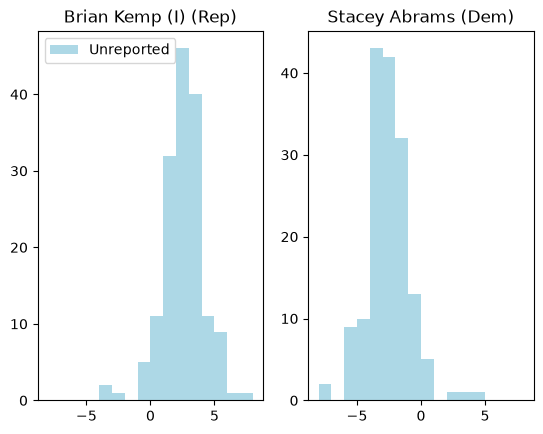

In [17]:
import numpy as np

prev_shares_county = pd.DataFrame(prev_votes_county)
for cand in prev_cands:
    prev_shares_county[cand] = prev_shares_county[cand] / prev_shares_county['Total Votes'] * 100

curr_shares_county = pd.DataFrame(curr_votes_county)
swings_county = pd.DataFrame(index=curr_shares_county.index)
for cand in curr_cands:
    curr_shares_county[cand] = curr_shares_county[cand] / curr_shares_county['Total Votes'] * 100
swings_county[kemp2022] = curr_shares_county[kemp2022] - prev_shares_county['BRIAN KEMP  (REP)']
swings_county[abrams2022] = curr_shares_county[abrams2022] - prev_shares_county['STACEY ABRAMS  (DEM)']

max_county_swing = swings_county.map(np.abs).max().max()
max_county_swing = int(np.ceil(max_county_swing))
range = (-max_county_swing, max_county_swing)
bins = max_county_swing * 2
fig, axes = plt.subplots(1, 2, squeeze=False)
for cand, ax in zip([kemp2022, abrams2022], axes[0]):
    ax.hist([swings_county[cand]], bins=bins, 
                    range=range, stacked=True, color=['lightblue'], 
                    label=['Unreported', 'Reported'])
    ax.set_title(cand)
axes[0][0].legend()

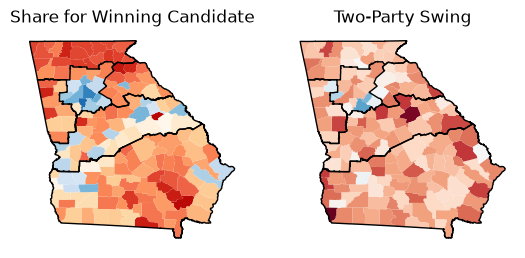

In [18]:
import geopandas
import matplotlib.colors as mcolors

curr_shares_county['geometry'] = counties['geometry']
swings_county['geometry'] = counties['geometry']
curr_shares_county = geopandas.GeoDataFrame(curr_shares_county)
swings_county = geopandas.GeoDataFrame(swings_county)
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True)

curr_shares_county['Region'] = swings_county['Region'] = counties['Region']
curr_shares_county['Subregion'] = swings_county['Subregion'] = counties['Subregion']

missing_kwds={
    'color': 'lightgray',
    'edgecolor': 'red',
    'hatch': '///',
    'label': 'Missing values'
}

# Share map
curr_shares_county[curr_shares_county[kemp2022] > 50]\
    .plot(column=kemp2022, ax=axes[0], #legend=True, 
          cmap='OrRd', missing_kwds=missing_kwds,
          legend_kwds={"label": "Kemp", "orientation": "horizontal"},
          norm=mcolors.Normalize(50, 100))
curr_shares_county[curr_shares_county[abrams2022] > 50]\
    .plot(column=abrams2022, ax=axes[0], #legend=True, 
          cmap='Blues', missing_kwds=missing_kwds,
          legend_kwds={"label": "Abrams", "orientation": "horizontal"},
          norm=mcolors.Normalize(40, 100))
curr_shares_county.dissolve(by='Region').plot(ax=axes[0], color='none')

# TPS Swing map
swings_county['TPS'] = swings_county[abrams2022] - swings_county[kemp2022] / 2
swings_county.plot(column='TPS', ax=axes[1], #legend=True, 
                   norm=mcolors.CenteredNorm(), cmap='RdBu')
swings_county.dissolve(by='Region').plot(ax=axes[1], color='none')

axes[0].set_title('Share for Winning Candidate')
axes[0].set_axis_off()
axes[1].set_title('Two-Party Swing')
axes[1].set_axis_off()